# Perceptron

---

![](https://upload.wikimedia.org/wikipedia/en/5/52/Mark_I_perceptron.jpeg)

*Mark I Perceptron machine, the first implementation of the perceptron algorithm*

This notebook implements the binary Perceptron in pure Python and compares it with the predefined `sklearn.linear_model.Perceptron`

---

## What is a Perceptron?

The Perceptron is one of the oldest and simplest supervised learning algorithms. It was invented by Frank Rosenblatt in 1957. You can think of it as a single artificial neuron that learns to classify data into two classes.

Given a data point $\mathbf{x} = (x_1, x_2, \ldots, x_d)$, the perceptron computes a weighted sum and produces a binary prediction:

$$z = \mathbf{w} \cdot \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + b$$

$$\hat{y} = \text{sign}(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

Where:
- $\mathbf{w}$ = weight vector (one weight per feature)
- $b$ = bias term (shifts the decision boundary)
- $\hat{y} \in \{-1, +1\}$ = predicted class label

---

## The Learning Rule

The perceptron updates its weights only when it makes a mistake. The update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} + y_i \cdot \mathbf{x}_i$$
$$b \leftarrow b + y_i$$

Where $y_i$ is the true label of the misclassified point.

If we predicted $-1$ but the true label is $+1$, we push the weights in the direction of $\mathbf{x}_i$. If we predicted $+1$ but the true label is $-1$, we push them in the opposite direction.

---

### Imports

In [ ]:
!pip install numpy matplotlib scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

# This makes the random results repeatable every time we run the notebook
np.random.seed(42)

### Generate Dataset

We create a simple 2D dataset with two classes

In [ ]:
X, y_raw = make_blobs(
    n_samples=100,
    centers=[(-2, -2), (2, 2)],
    cluster_std=0.9,
    random_state=42
)

y = np.where(y_raw == 0, -1, 1)

Visualization of the dataset

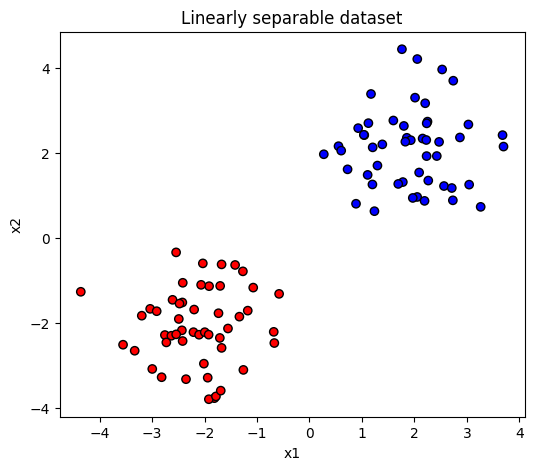

In [ ]:
colors = ['red' if label == -1 else 'blue' for label in y]

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k')
plt.title('Linearly separable dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Define Perceptron Class

In [ ]:
class Perceptron:
    def __init__(self, n_features, max_iter=100):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.max_iter = max_iter
        self.history = []

    def decision_function(self, X):
        X = np.asarray(X)
        return X @ self.weights + self.bias

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)

    def fit(self, X, y):
        for epoch in range(self.max_iter):
            errors = 0
            for xi, yi in zip(X, y):
                if yi * (np.dot(self.weights, xi) + self.bias) <= 0:
                    self.weights += yi * xi
                    self.bias += yi
                    errors += 1
            self.history.append(errors)
            if errors == 0:
                break
        return self

### Train the Perceptron

In [ ]:
model = Perceptron(n_features=2, max_iter=10)
model.fit(X, y)